# WN stim regen demo
Verifying that stim regen gives correct STA
VR 2025-07-08

In [1]:
import retinanalysis as ra
import numpy as np
import matplotlib.pyplot as plt
import tqdm.auto as tqdm

def compute_sta(cell_idx, e_idx, s1: ra.StimBlock, r1: ra.ResponseBlock, n_depth = 15):
    total_sps = r1.df_spike_times.at[cell_idx, 'binned_spikes'][e_idx].sum()
    print(f'Computing STA for cell idx {cell_idx} with total spikes: {total_sps}')
    lags = np.arange(0,n_depth)

    all_frames = s1.stim_data['frames']
    sta = np.zeros((len(lags), all_frames[0].shape[1], all_frames[0].shape[2]))
    pre_bins = r1.bin_rate * s1.df_epochs.at[0, 'epoch_parameters']['preTime'] * 1e-3
    pre_bins = np.round(pre_bins).astype(int)
    
    for i, lag in tqdm.tqdm(list(enumerate(lags)), desc="STA Depth"):
        # Only Red channel for simplicity
        frames = all_frames[0, :,:,:, 0]
        bs = r1.df_spike_times.at[cell_idx, 'binned_spikes'][e_idx, pre_bins:pre_bins + len(frames)]
        if lag > 0:
            bs = bs[lag:]
            frames = frames[:-lag]
        # Keep only timepoints with a spike
        mask = np.where(bs > 0)[0]
        if len(mask) == 0:
            print(f'No spikes found for cell idx {cell_idx} in epoch {e_idx}')
            continue
        bs = bs[mask]
        frames = frames[mask]
        frames = np.moveaxis(frames, 0, -1)
        sta[i] += np.matmul(frames, bs)
    return sta

[2026-05-08 14:50:25,877][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


In [2]:
# exp_name = '20251216C'
# datafile_name = 'data001'
exp_name = '20260415C'
datafile_name = 'data026'
# datafile_name = 'data002'
e_idx = 2
pp = ra.create_mea_pipeline(exp_name, datafile_name, b_load_vcd=True)
# pp.analysis_chunk.cell_ids==pp.resp.cell_ids

Initializing StimBlock for 20260415C block 4927
For Rig C 20260415C:
{'disp_type': 'LCR', 'mu_per_pixel': 3.34, 'n_ht': 1140, 'n_wt': 1824, 'mean_frame_rate': 59.94154881781792, 'stage_frame_rate': np.float64(59.0)}
Nearest noise chunk for data026 is chunk3 with distance 4 minutes.

Initializing ResponseBlock for 20260415C block 4927
Loading VCD from /mnt/Volumes/data-1/data/sorted/20260415C/data026/kilosort2.5 ...
VCD loaded with 419 cells.

Using chunk3 for AnalysisChunk

Loading VCD from /mnt/Volumes/data-1/analysis/20260415C/chunk3/kilosort2.5 ...
VCD loaded with 419 cells.


Loaded spatial maps for channels [0, 2] and 419 cells of shape (113, 182, 2)
Spatial maps have been padded to align with RF parameters.

Protocol is part of the sorting chunk, skipping cluster matching...
Using vr_kilosort2.5.classification.txt for classification.



Let's bin spike times.

In [22]:
pp.resp.bin_spike_times_by_frames()

Binning spikes for cells:   0%|          | 0/419 [00:00<?, ?it/s]

Mean frame rate: 59.94 Hz



Let's regenerate WN frames for the first epoch

In [23]:
pp.stim.regenerate_stimulus(ls_epochs=[e_idx])

Regenerating stimulus for epochs: [2] in block: 4927
Using regeneration function: make_spatial_noise


100%|██████████| 1/1 [00:03<00:00,  3.22s/it]


Regenerated stimulus with keys: ['frames', 'steps', 'canvas_size']


Let's use the compute_sta function defined up top to calculate and plot the STA for cell 2

In [30]:
len(pp.resp.cell_ids)

419

In [31]:
pp.resp.cell_ids[104]

np.int64(128)

In [38]:
print(pp.analysis_chunk.cell_ids[~(pp.analysis_chunk.cell_ids==pp.resp.cell_ids)])
print(pp.resp.cell_ids[~(pp.analysis_chunk.cell_ids==pp.resp.cell_ids)])

[115 116 117 118 119 120 121 122 123 125 126 127 128 130 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 151 152 153 154
 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 233 234
 235 236 238 239 240 241 242 243 244 245 246 247 248 250 252 253 254 255
 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273
 274 275 276 277 278 279 281 282 283 284 285 286 287 288 352 353 355 356
 357 359 360 361 365 366 368 370 371 372 373 374 375 376 377 378 379 380
 382 383 384 385 386 387 389 390 391 393 394 395 397 398 399 400 401 402
 403 404 405 406 407 408 409 410 411 412 413 414]
[128 130 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147
 148 149 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
 167 168 169 170 115 116 117 118 119 120 121 122 123 125 126 127 256 257
 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275
 276 277 278 279 281 282 283 284 285 286 287 288 233 234 235 236 238 239
 

Computing STA for cell idx 104 with total spikes: 4202.0


STA Depth:   0%|          | 0/15 [00:00<?, ?it/s]

Text(0.5, 0.98, 'Cell idx: 104, Cell id: 128')

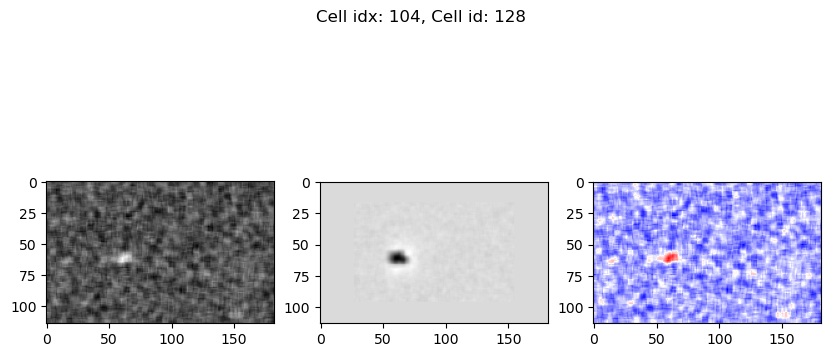

In [29]:
cell_idx = 104
sta = compute_sta(cell_idx, e_idx, pp.stim, pp.resp)

# Get Red channel spatial map, and peak pixel
cell_id = pp.resp.cell_ids[cell_idx]

sm = pp.analysis_chunk.d_spatial_maps[cell_id][:,:,0]
peak = np.unravel_index(np.argmax(sm), sm.shape)

# plt.plot(sta[:,peak[0], peak[1]])

plt.figure(figsize=(10, 5))
plt.subplot(131)
plt.imshow(sta[2,:,:], cmap='gray')
plt.subplot(132)
plt.imshow(sm, cmap='gray')
plt.subplot(133)
# Diff 
plt.imshow(sta[2,1:,1:] - sm, cmap='bwr')
# plt.colorbar()
plt.suptitle(f'Cell idx: {cell_idx}, Cell id: {cell_id}')